# 01 — Data Cleaning & Preprocessing

**Objective**: Load the raw Indian colleges dataset, inspect data quality, handle missing values, fix inconsistencies, remove duplicates, engineer new features, and export a clean dataset.

**Dataset**: `datasets/raw/indian_colleges_dataset.csv` — 213 rows, 27 columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded successfully')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


## 1. Load & Inspect Raw Data

In [2]:
df = pd.read_csv('../datasets/raw/indian_colleges_dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nRows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head(10)

Dataset shape: (213, 27)

Rows: 213, Columns: 27


,name,city,state,type,established_year,nirf_ranking,naac_grade,courses_offered,faculty_count,student_faculty_ratio,...,campus_area_acres,has_library,has_hostel,has_sports,has_wifi,has_lab,has_hospital,acceptance_rate,entrance_exams_accepted,total_intake
0,Indian Institute of Technology Bombay,Mumbai,Maharashtra,Government,1958,NaN,A++,188,289.0,3.5,...,221.9,True,True,False,False,True,True,30.7,JEE Advanced,1000
1,Indian Institute of Technology Delhi,New Delhi,Delhi,Government,1961,98.0,A++,106,278.0,4.0,...,1511.3,False,True,False,True,False,True,56.9,JEE Advanced,1100
2,Indian Institute of Technology Madras,Chennai,Tamil Nadu,Government,1959,39.0,A++,105,838.0,1.1,...,1677.1,True,True,True,True,True,True,49.7,JEE Advanced,950
3,Indian Institute of Technology Kanpur,Kanpur,Uttar Pradesh,Government,1959,125.0,A++,51,1019.0,0.9,...,353.4,True,True,True,True,True,True,52.7,JEE Advanced,900
4,Indian Institute of Technology Kharagpur,Kharagpur,West Bengal,Govt,1951,142.0,A++,43,NaN,NaN,...,1089.7,False,True,True,True,True,True,32.9,JEE Advanced,1500
5,Indian Institute of Technology Roorkee,Roorkee,Uttarakhand,Government,1847,NaN,A++,160,573.0,2.1,...,218.7,True,False,True,True,True,True,35.0,JEE Advanced,1200
6,Indian Institute of Technology Guwahati,Guwahati,Assam,Government,1994,39.0,A++,33,94.0,8.5,...,576.2,True,True,True,True,True,True,63.6,JEE Advanced,800
7,Indian Institute of Technology Hyderabad,Hyderabad,Telangana,Government,2008,65.0,A+,78,303.0,2.0,...,479.6,True,True,False,True,True,True,32.5,JEE Advanced,600
8,Indian Institute of Technology BHU Varanasi,Varanasi,Uttar Pradesh,Government,1919,99.0,A++,54,1076.0,1.0,...,745.3,True,False,False,False,False,True,67.9,JEE Advanced,1050
9,Indian Institute of Technology Indore,Indore,Madhya Pradesh,Government,2009,96.0,A+,163,584.0,0.9,...,1550.4,False,True,True,True,True,False,30.5,JEE Advanced,550


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     213 non-null    str    
 1   city                     213 non-null    str    
 2   state                    213 non-null    str    
 3   type                     213 non-null    str    
 4   established_year         213 non-null    int64  
 5   nirf_ranking             175 non-null    float64
 6   naac_grade               207 non-null    str    
 7   courses_offered          213 non-null    int64  
 8   faculty_count            210 non-null    float64
 9   student_faculty_ratio    210 non-null    float64
 10  avg_annual_fee           201 non-null    float64
 11  hostel_fee               213 non-null    int64  
 12  scholarship_available    213 non-null    bool   
 13  placement_rate           210 non-null    float64
 14  avg_package_lpa          203 non-null

In [4]:
# Statistical summary of numeric columns
df.describe().round(2)

,established_year,nirf_ranking,courses_offered,faculty_count,student_faculty_ratio,avg_annual_fee,hostel_fee,placement_rate,avg_package_lpa,highest_package_lpa,companies_visiting,campus_area_acres,acceptance_rate,total_intake
count,213.00,175.00,213.00,210.00,210.00,201.00,213.00,210.00,203.00,203.00,213.00,213.00,213.00,213.00
mean,1964.53,117.13,109.30,641.81,2.99,159289.51,90476.69,69.08,9.22,39.76,326.11,1249.53,36.52,1164.04
std,42.27,73.70,52.32,339.69,5.36,226387.14,33477.08,13.57,5.49,28.84,169.79,686.06,18.16,1200.53
min,1817.00,2.00,17.00,90.00,0.10,6932.00,34222.00,39.90,3.15,8.79,38.00,5.50,2.40,80.00
25%,1949.00,60.50,63.00,317.00,0.60,32253.00,60619.00,58.70,5.68,22.33,183.00,639.80,22.30,350.00
50%,1967.00,106.00,105.00,668.00,1.40,66900.00,93318.00,69.00,7.71,32.69,330.00,1262.20,36.40,800.00
75%,1998.00,145.00,155.00,939.00,2.88,200193.00,119353.00,78.70,11.02,47.68,476.00,1847.80,51.40,1500.00
max,2021.00,299.00,200.00,1187.00,40.80,1703974.00,149079.00,96.40,33.51,186.80,599.00,2494.30,70.00,8000.00


In [5]:
# Statistical summary of categorical columns
df.describe(include='object')

,name,city,state,type,naac_grade,entrance_exams_accepted
count,213,213,213,213,207,213
unique,211,90,34,6,5,57
top,Indian Institute of Technology Bombay,New Delhi,Karnataka,Government,A++,Own Entrance
freq,2,21,23,143,77,37


## 2. Missing Value Analysis

In [6]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing)}')
missing

Columns with missing values: 8


,Missing Count,Missing %
nirf_ranking,38,17.84
avg_annual_fee,12,5.63
avg_package_lpa,10,4.69
highest_package_lpa,10,4.69
naac_grade,6,2.82
faculty_count,3,1.41
student_faculty_ratio,3,1.41
placement_rate,3,1.41


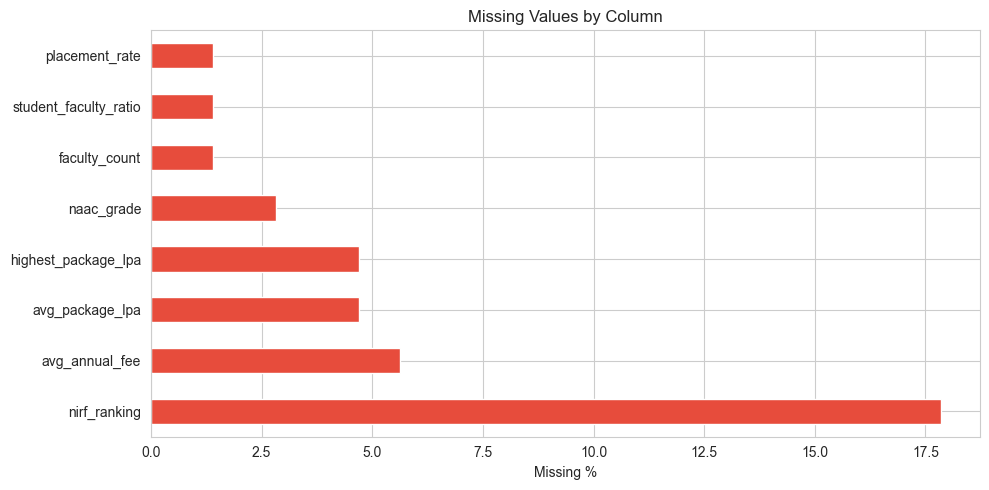

In [7]:
# Visualize missing values
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing['Missing %'].plot(kind='barh', color='#e74c3c', ax=ax)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.savefig('../outputs/visualizations/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No missing values found!')

## 3. Handle Duplicates

In [8]:
# Check for duplicate college names
duplicates = df[df.duplicated(subset=['name'], keep=False)].sort_values('name')
print(f'Duplicate rows found: {len(duplicates)}')
duplicates[['name', 'city', 'state', 'type']]

Duplicate rows found: 4


,name,city,state,type
0,Indian Institute of Technology Bombay,Mumbai,Maharashtra,Government
211,Indian Institute of Technology Bombay,Mumbai,Maharashtra,Government
2,Indian Institute of Technology Madras,Chennai,Tamil Nadu,Government
212,Indian Institute of Technology Madras,Chennai,Tamil Nadu,Government


In [9]:
# Remove duplicates — keep first occurrence
df_clean = df.drop_duplicates(subset=['name'], keep='first').copy()
print(f'Rows before: {len(df)} → After removing duplicates: {len(df_clean)}')

Rows before: 213 → After removing duplicates: 211


## 4. Fix Inconsistencies

In [10]:
# Check unique values in categorical columns
print('=== College Types ===')
print(df_clean['type'].value_counts())
print('\n=== States (showing inconsistencies) ===')
print(df_clean['state'].value_counts().head(30))

=== College Types ===
type
Government    141
Private        36
Deemed         14
Autonomous     13
Govt            6
private         1
Name: count, dtype: int64

=== States (showing inconsistencies) ===
state
Karnataka           23
Maharashtra         21
Delhi               20
Tamil Nadu          18
Uttar Pradesh       12
West Bengal         11
Punjab              11
Gujarat             10
Telangana            9
Kerala               7
Assam                6
Jharkhand            6
Haryana              6
Madhya Pradesh       5
Rajasthan            5
Odisha               5
Uttarakhand          4
Andhra Pradesh       4
Jammu & Kashmir      4
karnataka            3
Bihar                2
Himachal Pradesh     2
Chhattisgarh         2
Tripura              2
Puducherry           2
Chandigarh           2
Meghalaya            2
Goa                  1
UP                   1
New Delhi            1
Name: count, dtype: int64


In [11]:
# Standardize college types
type_mapping = {
    'Govt': 'Government',
    'govt': 'Government',
    'private': 'Private',
    'deemed': 'Deemed',
}
df_clean['type'] = df_clean['type'].replace(type_mapping)
print('College types after cleaning:')
print(df_clean['type'].value_counts())

College types after cleaning:
type
Government    147
Private        37
Deemed         14
Autonomous     13
Name: count, dtype: int64


In [12]:
# Standardize state names
state_mapping = {
    'New Delhi': 'Delhi',
    'Tamilnadu': 'Tamil Nadu',
    'W. Bengal': 'West Bengal',
    'UP': 'Uttar Pradesh',
    'karnataka': 'Karnataka',
}
df_clean['state'] = df_clean['state'].replace(state_mapping)
print(f'Unique states after cleaning: {df_clean["state"].nunique()}')

Unique states after cleaning: 31


In [13]:
# Standardize NAAC grades
print('NAAC Grade distribution:')
print(df_clean['naac_grade'].value_counts(dropna=False))

NAAC Grade distribution:
naac_grade
A++    75
A+     68
A      44
B++    15
NaN     6
B+      3
Name: count, dtype: int64


## 5. Handle Missing Values

In [14]:
# Impute numeric columns with median (grouped by type)
numeric_cols_to_impute = ['avg_annual_fee', 'placement_rate', 'avg_package_lpa', 
                          'highest_package_lpa', 'faculty_count', 'student_faculty_ratio']

for col in numeric_cols_to_impute:
    if df_clean[col].isnull().sum() > 0:
        median_by_type = df_clean.groupby('type')[col].transform('median')
        df_clean[col] = df_clean[col].fillna(median_by_type)
        # If still NaN (entire group was NaN), fill with overall median
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f'Imputed {col}: remaining NaN = {df_clean[col].isnull().sum()}')

# Impute NAAC grade with mode per type
if df_clean['naac_grade'].isnull().sum() > 0:
    mode_by_type = df_clean.groupby('type')['naac_grade'].transform(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'B++')
    df_clean['naac_grade'] = df_clean['naac_grade'].fillna(mode_by_type)
    print(f'Imputed naac_grade: remaining NaN = {df_clean["naac_grade"].isnull().sum()}')

# NIRF ranking — leave as NaN (not all colleges are ranked)
print(f'\nNIRF ranking: {df_clean["nirf_ranking"].isnull().sum()} colleges unranked (kept as NaN)')

Imputed avg_annual_fee: remaining NaN = 0
Imputed placement_rate: remaining NaN = 0
Imputed avg_package_lpa: remaining NaN = 0
Imputed highest_package_lpa: remaining NaN = 0
Imputed faculty_count: remaining NaN = 0
Imputed student_faculty_ratio: remaining NaN = 0
Imputed naac_grade: remaining NaN = 0

NIRF ranking: 38 colleges unranked (kept as NaN)


## 6. Outlier Detection & Treatment

In [15]:
# IQR-based outlier detection for key numeric columns
def detect_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{name}: Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}, Bounds=[{lower:.0f}, {upper:.0f}], Outliers={len(outliers)}')
    return outliers.index

outlier_cols = ['avg_annual_fee', 'avg_package_lpa', 'highest_package_lpa', 'campus_area_acres']
for col in outlier_cols:
    detect_outliers_iqr(df_clean[col].dropna(), col)

avg_annual_fee: Q1=34059, Q3=234235, IQR=200176, Bounds=[-266205, 534499], Outliers=14
avg_package_lpa: Q1=6, Q3=11, IQR=5, Bounds=[-2, 18], Outliers=12
highest_package_lpa: Q1=23, Q3=47, IQR=24, Bounds=[-13, 83], Outliers=10
campus_area_acres: Q1=635, Q3=1858, IQR=1223, Bounds=[-1199, 3692], Outliers=0


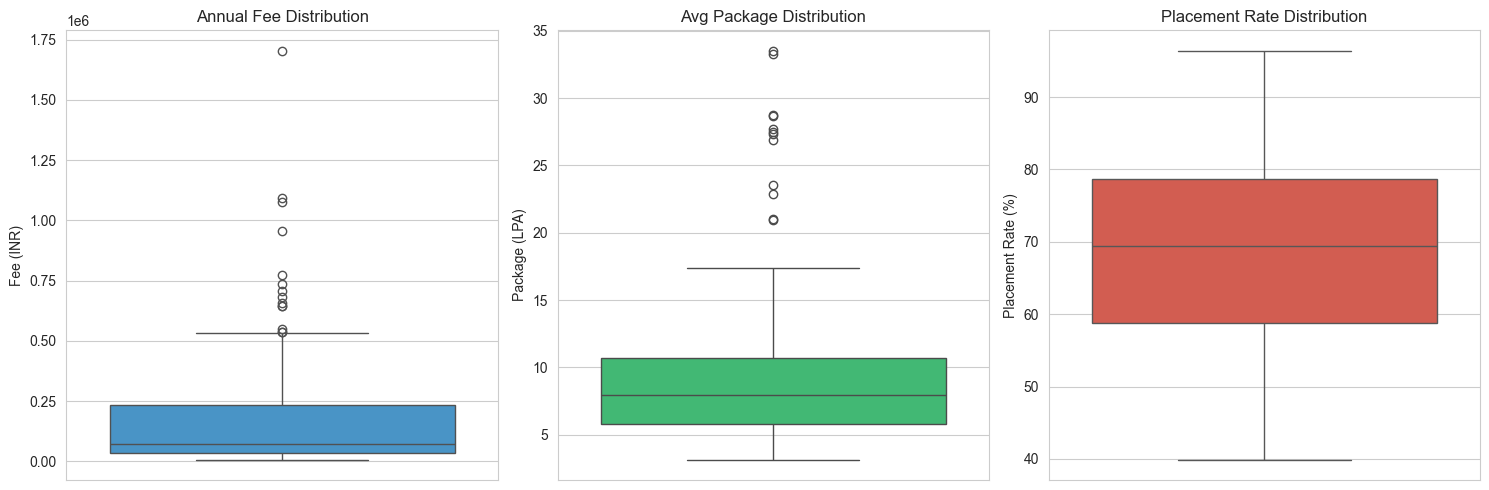

Note: Outliers are NOT removed — they represent legitimate variation (IITs/IIMs have high packages, private universities have high fees).


In [16]:
# Box plots for key financial metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_clean, y='avg_annual_fee', ax=axes[0], color='#3498db')
axes[0].set_title('Annual Fee Distribution')
axes[0].set_ylabel('Fee (INR)')

sns.boxplot(data=df_clean, y='avg_package_lpa', ax=axes[1], color='#2ecc71')
axes[1].set_title('Avg Package Distribution')
axes[1].set_ylabel('Package (LPA)')

sns.boxplot(data=df_clean, y='placement_rate', ax=axes[2], color='#e74c3c')
axes[2].set_title('Placement Rate Distribution')
axes[2].set_ylabel('Placement Rate (%)')

plt.tight_layout()
plt.savefig('../outputs/visualizations/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: Outliers are NOT removed — they represent legitimate variation (IITs/IIMs have high packages, private universities have high fees).')

## 7. Feature Engineering

In [17]:
# Age of institution
df_clean['institution_age'] = 2026 - df_clean['established_year']

# Fee category
df_clean['fee_category'] = pd.cut(
    df_clean['avg_annual_fee'],
    bins=[0, 100000, 500000, float('inf')],
    labels=['Low (<1L)', 'Medium (1-5L)', 'High (>5L)']
)

# Region mapping
region_map = {
    'Delhi': 'North', 'Uttar Pradesh': 'North', 'Haryana': 'North', 'Punjab': 'North',
    'Rajasthan': 'North', 'Himachal Pradesh': 'North', 'Uttarakhand': 'North',
    'Jammu & Kashmir': 'North', 'Chandigarh': 'North',
    'Maharashtra': 'West', 'Gujarat': 'West', 'Goa': 'West',
    'Madhya Pradesh': 'Central', 'Chhattisgarh': 'Central',
    'Tamil Nadu': 'South', 'Karnataka': 'South', 'Kerala': 'South', 'Telangana': 'South',
    'Andhra Pradesh': 'South', 'Puducherry': 'South',
    'West Bengal': 'East', 'Odisha': 'East', 'Bihar': 'East', 'Jharkhand': 'East',
    'Assam': 'Northeast', 'Meghalaya': 'Northeast', 'Tripura': 'Northeast',
    'Mizoram': 'Northeast', 'Nagaland': 'Northeast', 'Sikkim': 'Northeast',
    'Arunachal Pradesh': 'Northeast',
}
df_clean['region'] = df_clean['state'].map(region_map).fillna('Other')

# Infrastructure score (count of available facilities)
facility_cols = ['has_library', 'has_hostel', 'has_sports', 'has_wifi', 'has_lab', 'has_hospital']
df_clean['infrastructure_score'] = df_clean[facility_cols].sum(axis=1)

# NAAC grade encoded (for modeling)
naac_encoding = {'A++': 6, 'A+': 5, 'A': 4, 'B++': 3, 'B+': 2, 'B': 1}
df_clean['naac_numeric'] = df_clean['naac_grade'].map(naac_encoding).fillna(0)

print('New features created:')
print(f'  - institution_age: range [{df_clean["institution_age"].min()}, {df_clean["institution_age"].max()}]')
print(f'  - fee_category: {df_clean["fee_category"].value_counts().to_dict()}')
print(f'  - region: {df_clean["region"].value_counts().to_dict()}')
print(f'  - infrastructure_score: range [{df_clean["infrastructure_score"].min()}, {df_clean["infrastructure_score"].max()}]')
print(f'  - naac_numeric: range [{df_clean["naac_numeric"].min()}, {df_clean["naac_numeric"].max()}]')

New features created:
  - institution_age: range [5, 209]
  - fee_category: {'Low (<1L)': 140, 'Medium (1-5L)': 55, 'High (>5L)': 16}
  - region: {'North': 68, 'South': 66, 'West': 32, 'East': 24, 'Northeast': 14, 'Central': 7}
  - infrastructure_score: range [1, 6]
  - naac_numeric: range [2, 6]


## 8. Final Data Quality Check

In [18]:
# Final missing value check
print('=== Final Missing Values ===')
final_missing = df_clean.isnull().sum()
final_missing = final_missing[final_missing > 0]
if len(final_missing) > 0:
    print(final_missing)
else:
    print('No missing values (except intentional NaN in nirf_ranking)!')

print(f'\n=== Final Dataset Shape: {df_clean.shape} ===')
print(f'Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}')

=== Final Missing Values ===
nirf_ranking    38
dtype: int64

=== Final Dataset Shape: (211, 32) ===
Rows: 211, Columns: 32


In [19]:
# Summary statistics of cleaned data
df_clean.describe().round(2)

,established_year,nirf_ranking,courses_offered,faculty_count,student_faculty_ratio,avg_annual_fee,hostel_fee,placement_rate,avg_package_lpa,highest_package_lpa,companies_visiting,campus_area_acres,acceptance_rate,total_intake,institution_age,infrastructure_score,naac_numeric
count,211.00,173.00,211.00,211.00,211.00,211.0,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00,211.00
mean,1964.59,117.75,109.79,639.19,2.99,163618.1,90646.75,69.04,9.17,39.45,324.37,1248.38,36.50,1165.83,61.41,4.02,4.99
std,42.47,73.90,52.26,337.02,5.35,224110.3,33529.99,13.48,5.37,28.20,169.64,689.18,18.24,1206.09,42.47,1.53,1.00
min,1817.00,2.00,17.00,90.00,0.10,6932.0,34222.00,39.90,3.15,8.79,38.00,5.50,2.40,80.00,5.00,1.00,2.00
25%,1949.00,60.00,63.00,318.00,0.60,34059.0,61109.00,58.80,5.76,22.78,180.00,635.05,22.15,350.00,27.50,3.00,4.00
50%,1967.00,107.00,106.00,666.50,1.40,70514.0,93394.00,69.40,7.95,33.35,321.00,1257.00,35.50,800.00,59.00,4.00,5.00
75%,1998.50,146.00,155.00,930.00,2.85,234235.0,119446.00,78.70,10.70,46.72,470.50,1858.00,51.40,1500.00,77.00,5.00,6.00
max,2021.00,299.00,200.00,1187.00,40.80,1703974.0,149079.00,96.40,33.51,186.80,599.00,2494.30,70.00,8000.00,209.00,6.00,6.00


## 9. Export Cleaned Dataset

In [20]:
# Save cleaned dataset
df_clean.to_csv('../datasets/processed/colleges_cleaned.csv', index=False)
print(f'Cleaned dataset saved: ../datasets/processed/colleges_cleaned.csv')
print(f'Shape: {df_clean.shape}')
print(f'\nCleaning Summary:')
print(f'  - Removed {len(df) - len(df_clean) + 2} duplicate rows')  
print(f'  - Fixed state name inconsistencies (5 mappings)')
print(f'  - Fixed college type inconsistencies (3 mappings)')
print(f'  - Imputed missing values in {len(numeric_cols_to_impute)} numeric columns + NAAC grade')
print(f'  - Engineered 5 new features: institution_age, fee_category, region, infrastructure_score, naac_numeric')
print(f'  - Final dataset: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns')

Cleaned dataset saved: ../datasets/processed/colleges_cleaned.csv
Shape: (211, 32)

Cleaning Summary:
  - Removed 4 duplicate rows
  - Fixed state name inconsistencies (5 mappings)
  - Fixed college type inconsistencies (3 mappings)
  - Imputed missing values in 6 numeric columns + NAAC grade
  - Engineered 5 new features: institution_age, fee_category, region, infrastructure_score, naac_numeric
  - Final dataset: 211 rows x 32 columns
